In [35]:
import pandas as pd
import cvxopt 

In [36]:
data = pd.read_csv('./Iris.csv').drop('Id', axis=1)
data['Species'] = data['Species'].replace(to_replace=['Iris-setosa', 'Iris-virginica'], value=[0, 1])
data = data.loc[~(data['Species'] == 'Iris-versicolor')]
data = data.reset_index(drop=True)
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
95,6.7,3.0,5.2,2.3,1
96,6.3,2.5,5.0,1.9,1
97,6.5,3.0,5.2,2.0,1
98,6.2,3.4,5.4,2.3,1


In [37]:
import matplotlib.pyplot as plt

In [38]:
import matplotlib.patches as mpatches

In [39]:
x = data.drop(['Species', 'SepalWidthCm', 'SepalLengthCm'], axis=1).to_numpy()
y = data['Species'].to_numpy()
x.shape

(100, 2)

In [40]:
import numpy as np

In [41]:
def calculate_matrixes_hard_margin(x, y):
    n = x.shape[0]
    if len(np.unique(y))!=2:
        return
    q_matrix = np.array([-1 for i in range(n)]).reshape(n,1).astype(float)
    G_matrix = np.multiply(np.identity(n), -1).astype(float)
    h_matrix = np.array([0 for i in range(n)]).astype(float)
    y_values = np.array([-1 if value==np.unique(y)[0] else 1 for value in y]).reshape((1,n))
    A_matrix = np.array([-1 if value==np.unique(y)[0] else 1 for value in y]).astype(float)
    b_matrix = 0.0
    dot_x_matrix = np.dot(x, np.transpose(x))
    dot_y_matrix = np.dot(np.transpose(y_values), y_values)
    p_matrix = np.multiply(dot_x_matrix, dot_y_matrix).astype(float)
    return p_matrix, q_matrix, G_matrix, h_matrix, A_matrix, b_matrix, y_values

In [42]:
def cvxopt_solve_qp(P, q, G, h, A=None, b=None):
    n = x.shape[0]
    P = .5 * (P + P.T)  # make sure P is symmetric
    args = [cvxopt.matrix(P, (n, n), 'd'), cvxopt.matrix(q, (n,1), 'd')]
    args.extend([cvxopt.matrix(G, (n, n), 'd'), cvxopt.matrix(h, (n,1), 'd')])
    if A is not None:
        args.extend([cvxopt.matrix(A, (1, n), 'd'), cvxopt.matrix(b, (1, 1), 'd')])
    sol = cvxopt.solvers.qp(*args)
    if 'optimal' not in sol['status']:
        return None
    return np.array(sol['x']).reshape((P.shape[1],))

In [43]:
p_matrix, q_matrix, G_matrix, h_matrix, A_matrix, b_matrix, y_values = calculate_matrixes_hard_margin(x, y)

In [44]:
alphas_matrix = cvxopt_solve_qp(P=p_matrix, q=q_matrix, G=G_matrix, h=h_matrix, A=A_matrix, b=b_matrix)

     pcost       dcost       gap    pres   dres
 0: -3.0186e+00 -4.7617e+00  2e+02  1e+01  1e+00
 1: -6.8745e-01 -8.1523e-01  2e+01  2e+00  1e-01
 2:  4.8462e-02 -6.0931e-01  8e-01  7e-03  7e-04
 3: -1.2424e-01 -2.6538e-01  1e-01  9e-04  9e-05
 4: -1.6782e-01 -2.3832e-01  7e-02  4e-04  4e-05
 5: -2.0272e-01 -2.4258e-01  4e-02  5e-05  5e-06
 6: -2.3593e-01 -2.3719e-01  1e-03  8e-07  8e-08
 7: -2.3668e-01 -2.3669e-01  1e-05  8e-09  8e-10
 8: -2.3669e-01 -2.3669e-01  1e-07  8e-11  8e-12
Optimal solution found.


In [45]:
def calculate_w_b(a,x,y=y_values.reshape(x.shape[0])):
    w = np.dot((y*a).T, x)
    S = (a > 1e-5).flatten()
    b = np.mean(y[S] - np.dot(x[S], w.T))
    return w, b, S

In [46]:
w, b, S = calculate_w_b(a=alphas_matrix, x=x)

In [47]:
aw = -(w[0] / w[1])
aw

-2.000000125752376

In [48]:
b1 = x[S][0][1] - aw*x[S][0][0]

In [49]:
b2 = x[S][1][1] - aw*x[S][1][0]

In [50]:
middle_point = x[S][0] + (w/np.dot(w.T, w))

In [51]:
b_middle = middle_point[1] - aw*middle_point[0]

In [52]:
PetalLengthCm = data['PetalLengthCm'].tolist()
PetalWidthCm = data['PetalWidthCm'].tolist()
colors = ['red' if Species == 1 else 'blue' for Species in data['Species']]

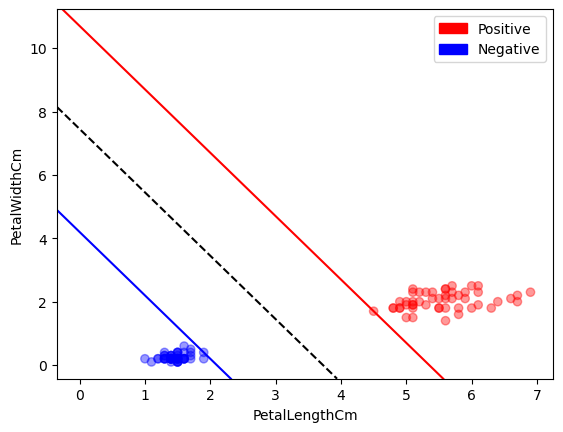

In [53]:
plt.scatter(x = PetalLengthCm, y = PetalWidthCm, alpha=0.4, color=colors)
plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
red_patch = mpatches.Patch(color='red', label='Positive')
blue_patch = mpatches.Patch(color='blue', label='Negative')
plt.axline((0, b1), slope=aw, color='blue', linestyle='-', label=f'y = {aw}x + {b}')
plt.axline((0, b2), slope=aw, color='red', linestyle='-', label=f'y = {aw}x + {b}')
plt.axline((0, b_middle), slope=aw, color='black', linestyle='--', label=f'y = {aw}x + {b}')
plt.legend(handles=[red_patch, blue_patch])

In [58]:
x_test = x[0:5]
y_test = y[0:5]
x_test

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

In [71]:
def calculate_matrixes_soft_margin(x, y, C):
    n = x.shape[0]
    if len(np.unique(y))!=2:
        return
    q_matrix = np.array([-1 for i in range(n)]).reshape(n,1).astype(float)
    G_matrix = np.vstack((np.multiply(np.identity(n), -1), np.identity(n))).astype(float)
    h_matrix = np.array([0 if i<n else C for i in range(2*n)]).astype(float)
    y_values = np.array([-1 if value==np.unique(y)[0] else 1 for value in y]).reshape((1,n))
    A_matrix = np.array([-1 if value==np.unique(y)[0] else 1 for value in y]).astype(float)
    b_matrix = 0.0
    dot_x_matrix = np.dot(x, np.transpose(x))
    dot_y_matrix = np.dot(np.transpose(y_values), y_values)
    p_matrix = np.multiply(dot_x_matrix, dot_y_matrix).astype(float)
    return p_matrix, q_matrix, G_matrix, h_matrix, A_matrix, b_matrix, y_values

In [72]:
p_matrix, q_matrix, G_matrix, h_matrix, A_matrix, b_matrix, y_values = calculate_matrixes_soft_margin(x,y,C=0.01)

In [73]:
def cvxopt_solve_qp_soft_margin(P, q, G, h, A=None, b=None):
    n = x.shape[0]
    P = .5 * (P + P.T)  # make sure P is symmetric
    args = [cvxopt.matrix(P, (n, n), 'd'), cvxopt.matrix(q, (n,1), 'd')]
    args.extend([cvxopt.matrix(G, (2*n, n), 'd'), cvxopt.matrix(h, (2*n,1), 'd')])
    if A is not None:
        args.extend([cvxopt.matrix(A, (1, n), 'd'), cvxopt.matrix(b, (1, 1), 'd')])
    sol = cvxopt.solvers.qp(*args)
    if 'optimal' not in sol['status']:
        return None
    return np.array(sol['x']).reshape((P.shape[1],))

In [74]:
alphas_matrix = cvxopt_solve_qp_soft_margin(P=p_matrix, q=q_matrix, G=G_matrix, h=h_matrix, A=A_matrix, b=b_matrix)

     pcost       dcost       gap    pres   dres
 0: -1.5864e+00 -1.3807e+00  3e+02  2e+01  5e-15
 1: -1.6630e-01 -1.3550e+00  7e+00  3e-01  4e-15
 2: -1.1336e-01 -9.0750e-01  8e-01  4e-03  9e-16
 3: -1.2342e-01 -2.1495e-01  9e-02  5e-04  8e-16
 4: -1.4227e-01 -1.6997e-01  3e-02  9e-05  8e-16
 5: -1.4854e-01 -1.5775e-01  9e-03  2e-05  1e-15
 6: -1.5187e-01 -1.5264e-01  8e-04  1e-06  1e-15
 7: -1.5211e-01 -1.5220e-01  8e-05  1e-07  1e-15
 8: -1.5215e-01 -1.5215e-01  2e-06  2e-09  9e-16
 9: -1.5215e-01 -1.5215e-01  2e-08  2e-11  9e-16
Optimal solution found.


In [75]:
def calculate_w_b(a,x,y=y_values.reshape(x.shape[0])):
    w = np.dot((y*a).T, x)
    S = (a > 1e-5).flatten()
    b = np.mean(y[S] - np.dot(x[S], w.T))
    ek_support_vectors = ((np.dot(x[S], w.T) + b) * y_values.reshape(100)[S] - 1)* -1
    return w, b, S, ek_support_vectors


In [76]:
w, b, S, ek = calculate_w_b(a=alphas_matrix, x=x)

In [77]:
x.shape

(100, 2)

In [78]:
def calculate_lines_2_d(x, w, S, y=y_values.reshape(x.shape[0])):
    if x.shape[1] != 2:
        return
    aw = -(w[0] / w[1])
    b_minuses = []
    b_pluses = []
    x_minus_list = []
    for i in range(y[S].shape[0]):
        if y[S][i] == -1:
            b_minuses.append(x[S][i][1] - aw*x[S][i][0])
            x_minus_list.append(x[S][i])
        else:
            b_pluses.append(x[S][i][1] - aw*x[S][i][0])
    b_minus = np.mean(b_minuses)
    b_plus = np.mean(b_pluses)
    middle_point = np.mean(np.array(x_minus_list), axis=0) + (w/np.dot(w.T, w))
    b_middle = middle_point[1] - aw*middle_point[0]
    return aw, b_minus, b_plus, b_middle
    
    

In [79]:
aw, b_minus, b_plus, b_middle = calculate_lines_2_d(x=x, w=w, S=S)

In [80]:
PetalLengthCm = data['PetalLengthCm'].tolist()
PetalWidthCm = data['PetalWidthCm'].tolist()
colors = ['red' if Species == 1 else 'blue' for Species in data['Species']]

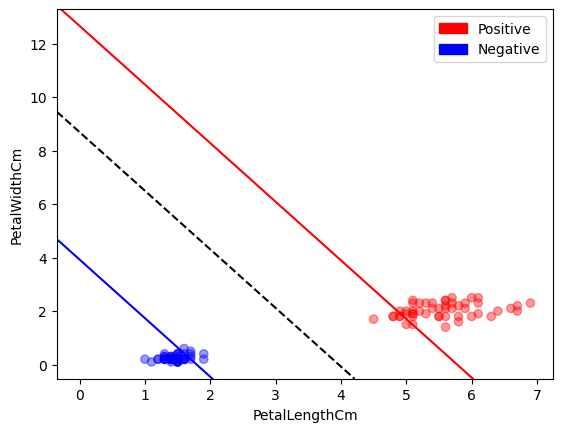

In [81]:
plt.scatter(x = PetalLengthCm, y = PetalWidthCm, alpha=0.4, color=colors)
plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
red_patch = mpatches.Patch(color='red', label='Positive')
blue_patch = mpatches.Patch(color='blue', label='Negative')
plt.axline((0, b_minus), slope=aw, color='blue', linestyle='-')
plt.axline((0, b_plus), slope=aw, color='red', linestyle='-')
plt.axline((0, b_middle), slope=aw, color='black', linestyle='--')
plt.legend(handles=[red_patch, blue_patch])
plt.show()

In [102]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=object)

In [103]:
y_values

array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1]])

In [105]:
np.unique(y)

array([0, 1], dtype=object)

In [108]:
def make_preds(x, y):
    neg_class = np.unique(y)[0]
    pos_class = np.unique(y)[1]
    y_preds = [neg_class if value<0 else pos_class for value in np.dot(x, w.T)+b]
    return y_preds


In [110]:
make_preds(x=x_test, y=y)

[0, 0, 0, 0, 0]

In [111]:
def calculate_distance_from_border(x, y=y_values.reshape(x.shape[0])):
    ek = y*(np.dot(x, w.T)+b) -1
    return ek